In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset

df = pd.read_csv("../Data/APL_Logistics.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 40


In [5]:
# Basic understanding of the dataset

print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class



Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         -----------

In [6]:
# ==========================================
# STEP 2: DATA QUALITY CHECK
# ==========================================

# 1. Check missing values
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# 2. Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# 3. Check target variable
print("\nLate Delivery Risk distribution:")
print(df["Late_delivery_risk"].value_counts())

# 4. Check target percentage
print("\nLate Delivery Risk percentage:")
print(df["Late_delivery_risk"].value_counts(normalize=True) * 100)

# 5. Check target unique values
print("\nTarget unique values:")
print(df["Late_delivery_risk"].unique())

Missing values:
Customer Lname                   8
Customer Zipcode                 3
Type                             0
Days for shipping (real)         0
Sales per customer               0
Delivery Status                  0
Days for shipment (scheduled)    0
Benefit per order                0
Category Id                      0
Late_delivery_risk               0
dtype: int64

Number of duplicate rows:
0

Late Delivery Risk distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late Delivery Risk percentage:
Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

Target unique values:
[1 0]


In [7]:
# ==========================================
# STEP 3: DATA CLEANING
# ==========================================

# Create a clean copy of the dataset
df_clean = df.dropna().copy()

# Check the new shape
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

# Check missing values again
print("\nTotal missing values after cleaning:")
print(df_clean.isnull().sum().sum())

# Check duplicates again
print("\nTotal duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape: (180519, 40)
Cleaned dataset shape: (180508, 40)

Total missing values after cleaning:
0

Total duplicate rows after cleaning:
0


In [8]:
# ==========================================
# STEP 4: EXPLORATORY DATA ANALYSIS
# ==========================================

# Separate numerical and categorical columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numerical columns: 21
Number of categorical columns: 19

Numerical columns:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']

Categorical columns:
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


C:\Users\parth\AppData\Local\Temp\ipykernel_23524\2861977192.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()


In [9]:
# ==========================================
# KEY EDA: LATE DELIVERY RISK BY BUSINESS FACTORS
# ==========================================

# 1. Late delivery risk by Shipping Mode
shipping_mode_risk = (
    df_clean.groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Late delivery risk by Shipping Mode (%):")
print(shipping_mode_risk.round(2))


# 2. Late delivery risk by scheduled shipping days
scheduled_days_risk = (
    df_clean.groupby("Days for shipment (scheduled)")["Late_delivery_risk"]
    .mean()
    .mul(100)
)

print("\nLate delivery risk by Scheduled Shipping Days (%):")
print(scheduled_days_risk.round(2))


# 3. Late delivery risk by Market
market_risk = (
    df_clean.groupby("Market")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nLate delivery risk by Market (%):")
print(market_risk.round(2))

Late delivery risk by Shipping Mode (%):
Shipping Mode
First Class       95.32
Second Class      76.63
Same Day          45.74
Standard Class    38.07
Name: Late_delivery_risk, dtype: float64

Late delivery risk by Scheduled Shipping Days (%):
Days for shipment (scheduled)
0    45.74
1    95.32
2    76.63
4    38.07
Name: Late_delivery_risk, dtype: float64

Late delivery risk by Market (%):
Market
Europe          55.21
Pacific Asia    55.05
USCA            54.80
Africa          54.59
LATAM           54.36
Name: Late_delivery_risk, dtype: float64


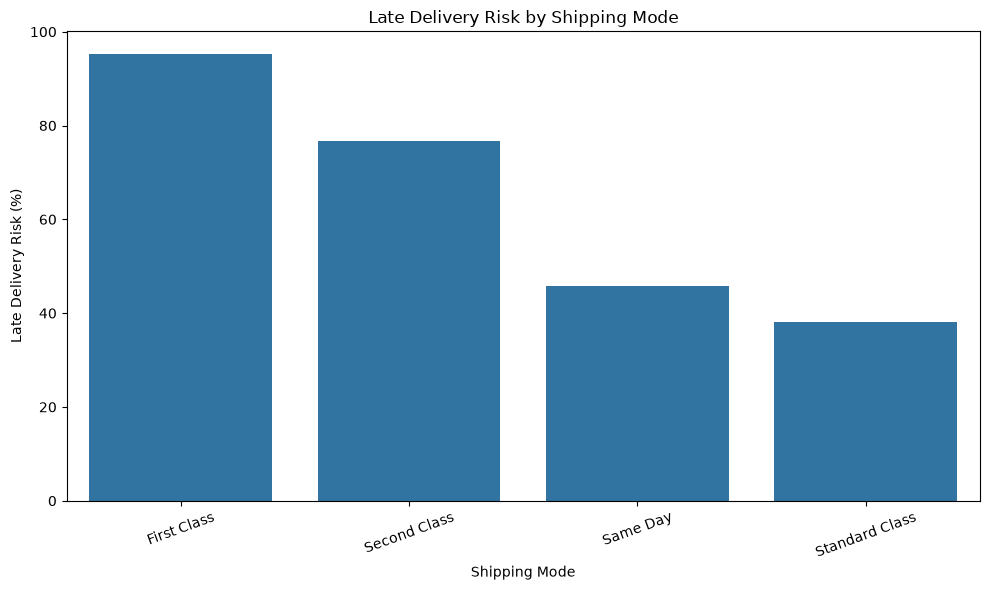

In [10]:
# ==========================================
# VISUALIZATION: LATE DELIVERY RISK
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=shipping_mode_risk.index,
    y=shipping_mode_risk.values
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# EDA: RISK BY CUSTOMER SEGMENT & DEPARTMENT
# ==========================================

# Customer Segment
segment_risk = (
    df_clean.groupby("Customer Segment")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Late delivery risk by Customer Segment (%):")
print(segment_risk.round(2))


# Department
department_risk = (
    df_clean.groupby("Department Name")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nLate delivery risk by Department (%):")
print(department_risk.round(2))

Late delivery risk by Customer Segment (%):
Customer Segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: Late_delivery_risk, dtype: float64

Late delivery risk by Department (%):
Department Name
Pet Shop              58.94
Book Shop             56.54
Health and Beauty     55.80
Fitness               55.55
Outdoors              55.49
Technology            54.96
Golf                  54.78
Fan Shop              54.77
Apparel               54.75
Footwear              54.73
Discs Shop            54.47
Name: Late_delivery_risk, dtype: float64


In [12]:
# ==========================================
# EDA: NUMERICAL FEATURES
# ==========================================

numeric_features = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Product Price",
    "Order Item Quantity"
]

# Keep only columns that actually exist
available_features = [
    col for col in numeric_features
    if col in df_clean.columns
]

print("Numerical features being analyzed:")
print(available_features)

# Correlation with target
correlation = (
    df_clean[available_features + ["Late_delivery_risk"]]
    .corr(numeric_only=True)["Late_delivery_risk"]
    .sort_values(ascending=False)
)

print("\nCorrelation with Late Delivery Risk:")
print(correlation.round(3))

Numerical features being analyzed:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Product Price', 'Order Item Quantity']

Correlation with Late Delivery Risk:
Late_delivery_risk               1.000
Days for shipping (real)         0.401
Order Item Quantity             -0.000
Product Price                   -0.002
Benefit per order               -0.004
Sales per customer              -0.004
Days for shipment (scheduled)   -0.369
Name: Late_delivery_risk, dtype: float64


In [13]:
# ==========================================
# CHECK TARGET LOGIC
# ==========================================

# Check whether actual shipping time exceeded scheduled time
calculated_risk = (
    df_clean["Days for shipping (real)"] >
    df_clean["Days for shipment (scheduled)"]
).astype(int)

# Compare calculated risk with existing target
comparison = (
    calculated_risk == df_clean["Late_delivery_risk"]
)

print("Percentage where calculated risk matches target:")
print(round(comparison.mean() * 100, 2), "%")

Percentage where calculated risk matches target:
97.55 %


In [14]:
# ==========================================
# STEP 4: FEATURE AVAILABILITY AUDIT
# ==========================================

print("All dataset columns:")
for i, col in enumerate(df_clean.columns, start=1):
    print(i, ":", col)

All dataset columns:
1 : Type
2 : Days for shipping (real)
3 : Days for shipment (scheduled)
4 : Benefit per order
5 : Sales per customer
6 : Delivery Status
7 : Late_delivery_risk
8 : Category Id
9 : Category Name
10 : Customer City
11 : Customer Country
12 : Customer Fname
13 : Customer Id
14 : Customer Lname
15 : Customer Segment
16 : Customer State
17 : Customer Street
18 : Customer Zipcode
19 : Department Id
20 : Department Name
21 : Latitude
22 : Longitude
23 : Market
24 : Order City
25 : Order Country
26 : Order Customer Id
27 : Order Item Discount
28 : Order Item Discount Rate
29 : Order Item Product Price
30 : Order Item Profit Ratio
31 : Order Item Quantity
32 : Sales
33 : Order Item Total
34 : Order Profit Per Order
35 : Order Region
36 : Order State
37 : Order Status
38 : Product Name
39 : Product Price
40 : Shipping Mode


In [15]:
# ==========================================
# TARGET LOGIC ANALYSIS
# ==========================================

print("Target distribution:")
print(df_clean["Late_delivery_risk"].value_counts())

print("\nTarget percentage:")
print(
    df_clean["Late_delivery_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nAverage actual shipping days by target:")
print(
    df_clean.groupby("Late_delivery_risk")["Days for shipping (real)"]
    .mean()
    .round(2)
)

print("\nAverage scheduled shipping days by target:")
print(
    df_clean.groupby("Late_delivery_risk")["Days for shipment (scheduled)"]
    .mean()
    .round(2)
)

Target distribution:
Late_delivery_risk
1    98972
0    81536
Name: count, dtype: int64

Target percentage:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

Average actual shipping days by target:
Late_delivery_risk
0    2.78
1    4.09
Name: Days for shipping (real), dtype: float64

Average scheduled shipping days by target:
Late_delivery_risk
0    3.49
1    2.47
Name: Days for shipment (scheduled), dtype: float64


In [16]:
# ==========================================
# TARGET MISMATCH ANALYSIS
# ==========================================

mismatch = df_clean[
    calculated_risk != df_clean["Late_delivery_risk"]
]

print("Number of mismatched records:", len(mismatch))

print("\nMismatch percentage:")
print(round(len(mismatch) / len(df_clean) * 100, 2), "%")

print("\nExamples of mismatched records:")

display(
    mismatch[
        [
            "Days for shipping (real)",
            "Days for shipment (scheduled)",
            "Delivery Status",
            "Late_delivery_risk"
        ]
    ].head(10)
)

Number of mismatched records: 4423

Mismatch percentage:
2.45 %

Examples of mismatched records:


,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk
244,5,4,Shipping canceled,0
246,5,4,Shipping canceled,0
247,5,4,Shipping canceled,0
320,2,1,Shipping canceled,0
321,2,1,Shipping canceled,0
324,2,1,Shipping canceled,0
332,3,2,Shipping canceled,0
333,3,2,Shipping canceled,0
334,3,2,Shipping canceled,0
341,3,2,Shipping canceled,0


In [17]:
# ==========================================
# MISMATCH ANALYSIS BY DELIVERY STATUS
# ==========================================

print("Mismatch records by Delivery Status:")

mismatch_status = (
    mismatch["Delivery Status"]
    .value_counts()
)

print(mismatch_status)

print("\nMismatch percentage by Delivery Status:")

mismatch_status_percentage = (
    mismatch["Delivery Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(mismatch_status_percentage)

Mismatch records by Delivery Status:
Delivery Status
Shipping canceled    4423
Name: count, dtype: int64

Mismatch percentage by Delivery Status:
Delivery Status
Shipping canceled    100.0
Name: proportion, dtype: float64


In [18]:
# ==========================================
# LATE DELIVERY RISK BY DELIVERY STATUS
# ==========================================

delivery_status_risk = (
    df_clean.groupby("Delivery Status")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("Late delivery risk by Delivery Status (%):")
print(delivery_status_risk)

Late delivery risk by Delivery Status (%):
Delivery Status
Late delivery        100.0
Advance shipping       0.0
Shipping canceled      0.0
Shipping on time       0.0
Name: Late_delivery_risk, dtype: float64


In [19]:
# ==========================================
# STEP 5: FEATURE AVAILABILITY / LEAKAGE AUDIT
# ==========================================

print("FEATURE AVAILABILITY AUDIT")
print("=" * 50)

# Target column
target = "Late_delivery_risk"

# Features that are clearly known only after/during delivery
potential_leakage = [
    "Days for shipping (real)",
    "Delivery Status"
]

# Check which leakage columns actually exist
leakage_columns = [
    col for col in potential_leakage
    if col in df_clean.columns
]

print("\nPotential leakage columns:")
for col in leakage_columns:
    print("-", col)

# Features that are known at order/shipment planning time
known_at_order = [
    "Type",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Category Id",
    "Category Name",
    "Customer City",
    "Customer Country",
    "Customer Segment",
    "Customer State",
    "Customer Zipcode",
    "Department Id",
    "Department Name",
    "Market",
    "Order City",
    "Order Country",
    "Order Item Quantity",
    "Product Name",
    "Product Price",
    "Shipping Mode"
]

available_features = [
    col for col in known_at_order
    if col in df_clean.columns
]

print("\nPotential prediction features:")
for col in available_features:
    print("-", col)

print("\nNumber of potential prediction features:",
      len(available_features))

FEATURE AVAILABILITY AUDIT

Potential leakage columns:
- Days for shipping (real)
- Delivery Status

Potential prediction features:
- Type
- Days for shipment (scheduled)
- Benefit per order
- Sales per customer
- Category Id
- Category Name
- Customer City
- Customer Country
- Customer Segment
- Customer State
- Customer Zipcode
- Department Id
- Department Name
- Market
- Order City
- Order Country
- Order Item Quantity
- Product Name
- Product Price
- Shipping Mode

Number of potential prediction features: 20


In [20]:
# ==========================================
# STEP 5: FINAL FEATURE SELECTION
# ==========================================

# Features available before delivery outcome
features = [
    "Type",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Category Name",
    "Customer Segment",
    "Customer Country",
    "Customer State",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Product Price",
    "Shipping Mode"
]

target = "Late_delivery_risk"

# Create X and y
X = df_clean[features].copy()
y = df_clean[target].copy()

print("Final features:")
for i, col in enumerate(X.columns, start=1):
    print(i, ":", col)

print("\nNumber of features:", X.shape[1])
print("Number of records:", X.shape[0])

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Final features:
1 : Type
2 : Days for shipment (scheduled)
3 : Benefit per order
4 : Sales per customer
5 : Category Name
6 : Customer Segment
7 : Customer Country
8 : Customer State
9 : Department Name
10 : Market
11 : Order Country
12 : Order Region
13 : Product Price
14 : Shipping Mode

Number of features: 14
Number of records: 180508

Target distribution:
Late_delivery_risk
1    98972
0    81536
Name: count, dtype: int64

Target percentage:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [23]:
# ==========================================
# STEP 6: TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training data shape: (144406, 14)
Testing data shape: (36102, 14)

Training target distribution:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

Testing target distribution:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [22]:
%pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     -------------------------------------- 61.0/61.0 kB 650.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB 8.9 MB/s eta 0:00:01
   -- ------------------------------------- 0.6/8.3 MB 7.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.3 MB 7.5 MB/s eta 0:00:01
   ----- ---------------------------------- 1.2/8.3 MB 7.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.3 MB 7.1 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.3 MB 6.9 MB/s eta 0:00:01
   --------- ------------------------------ 2.1/8.3 MB 7.0 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.3 MB 6.9 MB/s eta 0:00:01
   ------------- -------------------------- 2.7/8.3 MB 7.0 MB/s eta 0:00:01
   --------------- ---


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\parth\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
# ==========================================
# STEP 7: CATEGORICAL ENCODING
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features
numeric_features = [
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Product Price"
]

# Categorical features
categorical_features = [
    "Type",
    "Category Name",
    "Customer Segment",
    "Customer Country",
    "Customer State",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Shipping Mode"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

# Fit ONLY on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted encoder
X_test_encoded = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Encoded training shape:", X_train_encoded.shape)

print("Original testing shape:", X_test.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Original training shape: (144406, 14)
Encoded training shape: (144406, 313)
Original testing shape: (36102, 14)
Encoded testing shape: (36102, 313)


In [25]:
# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [26]:
print("X_train columns:")
print(X_train.columns.tolist())

X_train columns:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Name', 'Customer Segment', 'Customer Country', 'Customer State', 'Department Name', 'Market', 'Order Country', 'Order Region', 'Product Price', 'Shipping Mode']


In [27]:
# ============================================
# STEP 7: FEATURE ENCODING
# ============================================

# Fit the preprocessor ONLY on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_encoded = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Encoded training shape:", X_train_encoded.shape)

print("Original testing shape:", X_test.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Original training shape: (144406, 14)
Encoded training shape: (144406, 313)
Original testing shape: (36102, 14)
Encoded testing shape: (36102, 313)


In [28]:
# ============================================
# STEP 8: BASELINE MODEL
# ============================================

from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [29]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    random_state=42
)

print("Model created successfully.")

Model created successfully.


In [30]:
# Train the Logistic Regression model

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_encoded,
    y_train
)

print("Training completed successfully.")

Training Logistic Regression...
Training completed successfully.


C:\Users\parth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [31]:
# Make predictions on test data

y_pred = logistic_model.predict(X_test_encoded)

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 36102


In [32]:
# ============================================
# MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("=================")

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Model Performance
Accuracy : 68.97 %
Precision: 79.18 %
Recall   : 58.88 %
F1 Score : 67.54 %


In [33]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[13242  3065]
 [ 8139 11656]]


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.81      0.70     16307
           1       0.79      0.59      0.68     19795

    accuracy                           0.69     36102
   macro avg       0.71      0.70      0.69     36102
weighted avg       0.71      0.69      0.69     36102



In [35]:
# ============================================
# STEP 9: ROC-AUC EVALUATION
# ============================================

from sklearn.metrics import roc_auc_score

# Get probability of class 1
y_pred_proba = logistic_model.predict_proba(X_test_encoded)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.7264


In [36]:
# ============================================
# STEP 10: RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [37]:
# ============================================
# TRAIN RANDOM FOREST
# ============================================

print("Training Random Forest...")

random_forest_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest training completed successfully.")

Training Random Forest...
Random Forest training completed successfully.


In [38]:
# ============================================
# RANDOM FOREST PREDICTIONS
# ============================================

y_pred_rf = random_forest_model.predict(X_test_encoded)

print("Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions completed.
Number of predictions: 36102


In [39]:
# ============================================
# RANDOM FOREST EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("==========================")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
Accuracy : 71.28 %
Precision: 76.39 %
Recall   : 68.93 %
F1 Score : 72.47 %

Confusion Matrix:
[[12089  4218]
 [ 6150 13645]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70     16307
           1       0.76      0.69      0.72     19795

    accuracy                           0.71     36102
   macro avg       0.71      0.72      0.71     36102
weighted avg       0.72      0.71      0.71     36102



In [40]:
# ============================================
# RANDOM FOREST ROC-AUC
# ============================================

y_pred_rf_proba = random_forest_model.predict_proba(
    X_test_encoded
)[:, 1]

rf_roc_auc = roc_auc_score(
    y_test,
    y_pred_rf_proba
)

print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))

Random Forest ROC-AUC: 0.7851


In [41]:
# ============================================
# STEP 11: MODEL COMPARISON
# ============================================

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

# Convert to percentage
model_comparison[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]] = model_comparison[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]] * 100

print("MODEL COMPARISON")
print("================")
print(model_comparison.round(2))

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     68.97      79.18   58.88     67.54     0.73
1        Random Forest     71.28      76.39   68.93     72.47     0.79


In [42]:
# ============================================
# STEP 12: RANDOM FOREST FEATURE IMPORTANCE
# ============================================

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Get importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 20 IMPORTANT FEATURES")
print("=========================")

print(feature_importance.head(20).to_string(index=False))

TOP 20 IMPORTANT FEATURES
                                  Feature  Importance
             remainder__Benefit per order    0.165758
            remainder__Sales per customer    0.147826
 remainder__Days for shipment (scheduled)    0.078689
categorical__Shipping Mode_Standard Class    0.063302
   categorical__Shipping Mode_First Class    0.040786
                 remainder__Product Price    0.027275
  categorical__Shipping Mode_Second Class    0.018680
   categorical__Customer Segment_Consumer    0.016578
  categorical__Customer Segment_Corporate    0.014856
categorical__Customer Segment_Home Office    0.012701
           categorical__Customer State_CA    0.012645
           categorical__Customer State_NY    0.008184
      categorical__Shipping Mode_Same Day    0.007640
                  categorical__Type_DEBIT    0.007526
           categorical__Customer State_TX    0.006983
                categorical__Type_PAYMENT    0.006878
    categorical__Department Name_Fan Shop    0.006782
  

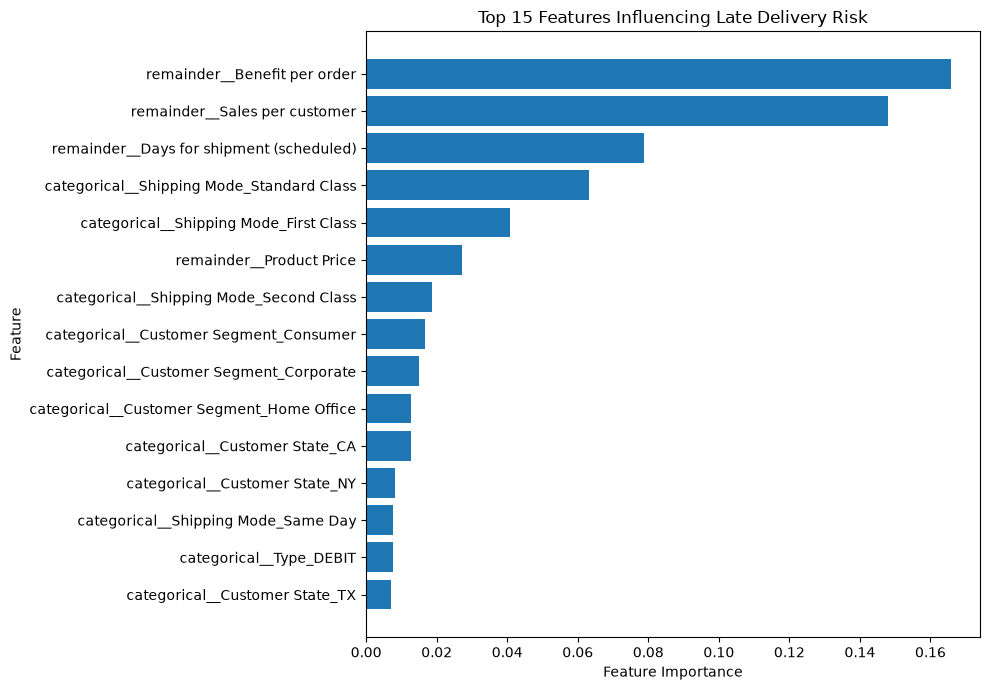

In [43]:
# ============================================
# STEP 13: FEATURE IMPORTANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# Select top 15 features
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Late Delivery Risk")

plt.tight_layout()
plt.show()

In [44]:
# ============================================
# STEP 14: TUNED RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create a tuned Random Forest
tuned_rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("Training Tuned Random Forest...")

tuned_rf.fit(
    X_train_encoded,
    y_train
)

print("Tuned Random Forest training completed successfully.")

Training Tuned Random Forest...
Tuned Random Forest training completed successfully.


In [45]:
# ============================================
# TUNED RANDOM FOREST PREDICTIONS
# ============================================

y_pred_tuned = tuned_rf.predict(X_test_encoded)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_tuned))

Predictions completed.
Number of predictions: 36102


In [46]:
# ============================================
# TUNED RANDOM FOREST PERFORMANCE
# ============================================

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("TUNED RANDOM FOREST PERFORMANCE")
print("================================")
print("Accuracy :", round(tuned_accuracy * 100, 2), "%")
print("Precision:", round(tuned_precision * 100, 2), "%")
print("Recall   :", round(tuned_recall * 100, 2), "%")
print("F1 Score :", round(tuned_f1 * 100, 2), "%")

TUNED RANDOM FOREST PERFORMANCE
Accuracy : 69.92 %
Precision: 82.65 %
Recall   : 57.13 %
F1 Score : 67.56 %


In [47]:
# ============================================
# TUNED RANDOM FOREST ROC-AUC
# ============================================

y_pred_tuned_proba = tuned_rf.predict_proba(
    X_test_encoded
)[:, 1]

tuned_roc_auc = roc_auc_score(
    y_test,
    y_pred_tuned_proba
)

print("Tuned Random Forest ROC-AUC:",
      round(tuned_roc_auc, 4))

Tuned Random Forest ROC-AUC: 0.7645


In [48]:
# ============================================
# STEP 15: FINAL MODEL COMPARISON
# ============================================

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        tuned_accuracy
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        tuned_precision
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        tuned_recall
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        tuned_f1
    ],
    
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        tuned_roc_auc
    ]
})

# Convert to percentage
final_comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] *= 100

print("FINAL MODEL COMPARISON")
print("======================")

print(
    final_comparison.round(2)
)

FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     68.97      79.18   58.88     67.54     0.73
1        Random Forest     71.28      76.39   68.93     72.47     0.79
2  Tuned Random Forest     69.92      82.65   57.13     67.56     0.76


In [49]:
# ============================================
# STEP 16: SAVE FINAL MODEL
# ============================================

import joblib
from pathlib import Path

# Create models folder if it doesn't exist
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

# Save the selected Random Forest model
joblib.dump(
    random_forest_model,
    models_path / "random_forest_model.pkl"
)

print("Final Random Forest model saved successfully.")
print("Location:", models_path / "random_forest_model.pkl")

Final Random Forest model saved successfully.
Location: ..\models\random_forest_model.pkl


In [50]:
# ============================================
# STEP 17: SAVE PREPROCESSOR
# ============================================

joblib.dump(
    preprocessor,
    models_path / "preprocessor.pkl"
)

print("Preprocessor saved successfully.")
print("Location:", models_path / "preprocessor.pkl")

Preprocessor saved successfully.
Location: ..\models\preprocessor.pkl


In [51]:
# ============================================
# STEP 18: SAVE FEATURE INFORMATION
# ============================================

feature_info = {
    "features": X_train.columns.tolist(),
    "target": "Late_delivery_risk"
}

joblib.dump(
    feature_info,
    models_path / "feature_info.pkl"
)

print("Feature information saved successfully.")
print("Features used by model:")

for i, feature in enumerate(feature_info["features"], 1):
    print(f"{i}. {feature}")

Feature information saved successfully.
Features used by model:
1. Type
2. Days for shipment (scheduled)
3. Benefit per order
4. Sales per customer
5. Category Name
6. Customer Segment
7. Customer Country
8. Customer State
9. Department Name
10. Market
11. Order Country
12. Order Region
13. Product Price
14. Shipping Mode


In [52]:
# ============================================
# STEP 20: LOAD SAVED MODEL AND TEST PREDICTION
# ============================================

import joblib

# Load saved model
loaded_model = joblib.load(
    models_path / "random_forest_model.pkl"
)

# Load saved preprocessor
loaded_preprocessor = joblib.load(
    models_path / "preprocessor.pkl"
)

# Take one sample from test data
sample = X_test.iloc[[0]]

# Get actual target value
actual_value = y_test.iloc[0]

# Transform sample using saved preprocessor
sample_encoded = loaded_preprocessor.transform(sample)

# Make prediction
prediction = loaded_model.predict(sample_encoded)[0]

# Get probability
prediction_probability = loaded_model.predict_proba(sample_encoded)[0][1]

print("SAVED MODEL TEST")
print("================")
print("Actual value     :", actual_value)
print("Predicted value  :", prediction)
print("Late risk probability :", round(prediction_probability * 100, 2), "%")

SAVED MODEL TEST
Actual value     : 0
Predicted value  : 0
Late risk probability : 32.0 %


In [53]:
# ============================================
# STEP 21: HUMAN-READABLE PREDICTION
# ============================================

if prediction == 1:
    risk_status = "HIGH RISK - Likely Late Delivery"
else:
    risk_status = "LOW RISK - Likely On-Time Delivery"

print("Delivery Risk Prediction")
print("=========================")
print("Prediction:", risk_status)
print("Probability of Late Delivery:",
      round(prediction_probability * 100, 2), "%")

Delivery Risk Prediction
Prediction: LOW RISK - Likely On-Time Delivery
Probability of Late Delivery: 32.0 %


In [54]:
# ============================================
# STEP 22: CREATE PREDICTION FUNCTION
# ============================================

def predict_late_delivery(input_data):
    
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Transform input using saved preprocessor
    input_encoded = loaded_preprocessor.transform(input_df)
    
    # Make prediction
    prediction = loaded_model.predict(input_encoded)[0]
    
    # Get probability of late delivery
    probability = loaded_model.predict_proba(input_encoded)[0][1]
    
    # Convert prediction into readable result
    if prediction == 1:
        risk_status = "HIGH RISK - Likely Late Delivery"
    else:
        risk_status = "LOW RISK - Likely On-Time Delivery"
    
    return {
        "prediction": prediction,
        "risk_status": risk_status,
        "late_probability": probability
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [55]:
# ============================================
# STEP 23: TEST PREDICTION FUNCTION
# ============================================

test_input = X_test.iloc[0].to_dict()

result = predict_late_delivery(test_input)

print("PREDICTION RESULT")
print("=================")
print("Prediction:", result["risk_status"])
print(
    "Late Delivery Probability:",
    round(result["late_probability"] * 100, 2),
    "%"
)

PREDICTION RESULT
Prediction: LOW RISK - Likely On-Time Delivery
Late Delivery Probability: 32.0 %
